<a href="https://colab.research.google.com/github/DastanJin/ZSU/blob/main/Project1_SUS0112.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

plt.style.use("ggplot")
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_context("talk")

In [3]:
df = pd.read_csv("computer_prices_all.csv")
df.head()

,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,...,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,...,2560x1440,90.0,0.0,0.0,750.0,Wi-Fi 6,5.1,11.00,36.0,1383.99
1,Laptop,Samsung,Samsung Pro KM8,2022,Windows,Mainstream,Intel,Intel i7-11114,4,12,...,1920x1080,90.0,56.0,120.0,0.0,Wi-Fi 6,5.3,2.03,12.0,2274.99
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,...,3440x1440,120.0,0.0,0.0,850.0,Wi-Fi 6,5.0,7.00,24.0,1879.99
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,...,3440x1440,120.0,0.0,0.0,650.0,Wi-Fi 6,5.2,6.00,36.0,1331.99
4,Laptop,Gigabyte,Gigabyte Pro IX1,2024,Linux,Gaming,AMD,AMD Ryzen 7 6230,5,16,...,2560x1600,90.0,80.0,90.0,0.0,Wi-Fi 6,5.2,1.50,12.0,2681.99


In [4]:
df.info()      # dá ti seznam sloupců + jejich typy + počet non-null hodnot
df.describe(include='all')  # statistiky + ukázku kategoriálních sloupců


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92742 entries, 0 to 92741
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   device_type          92742 non-null  object 
 1   brand                92742 non-null  object 
 2   model                92742 non-null  object 
 3   release_year         92742 non-null  int64  
 4   os                   92742 non-null  object 
 5   form_factor          92742 non-null  object 
 6   cpu_brand            92742 non-null  object 
 7   cpu_model            92742 non-null  object 
 8   cpu_tier             92742 non-null  int64  
 9   cpu_cores            92742 non-null  int64  
 10  cpu_threads          92742 non-null  int64  
 11  cpu_base_ghz         92742 non-null  float64
 12  cpu_boost_ghz        92742 non-null  float64
 13  gpu_brand            92741 non-null  object 
 14  gpu_model            92741 non-null  object 
 15  gpu_tier             92741 non-null 

,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,...,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
count,92742,92742,92742,92742.000000,92742,92742,92742,92742,92742.000000,92742.000000,...,92741,92741.000000,92741.000000,92741.000000,92741.000000,92741,92741.000000,92741.000000,92741.000000,92741.000000
unique,2,10,91930,NaN,4,10,3,26421,NaN,NaN,...,6,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN
top,Laptop,Lenovo,HP Creator R41,NaN,Windows,Mainstream,Intel,Apple M2 Pro,NaN,NaN,...,1920x1080,NaN,NaN,NaN,NaN,Wi-Fi 6,NaN,NaN,NaN,NaN
freq,55500,14799,3,NaN,66555,16522,48944,1289,NaN,NaN,...,44530,NaN,NaN,NaN,NaN,42823,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2022.321677,NaN,NaN,NaN,NaN,3.152347,10.511160,...,NaN,98.448302,41.817653,61.354795,272.554749,NaN,5.084684,4.289752,22.206230,1927.861740
std,NaN,NaN,NaN,2.026821,NaN,NaN,NaN,NaN,1.372771,5.042723,...,NaN,43.324880,35.871616,62.743797,354.685565,NaN,0.245892,3.814904,10.228434,580.207822
min,NaN,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN,1.000000,4.000000,...,NaN,60.000000,0.000000,0.000000,0.000000,NaN,4.200000,0.920000,12.000000,372.990000
25%,NaN,NaN,NaN,2021.000000,NaN,NaN,NaN,NaN,2.000000,6.000000,...,NaN,60.000000,0.000000,0.000000,0.000000,NaN,5.000000,1.500000,12.000000,1501.990000
50%,NaN,NaN,NaN,2023.000000,NaN,NaN,NaN,NaN,3.000000,8.000000,...,NaN,90.000000,56.000000,65.000000,0.000000,NaN,5.100000,2.000000,24.000000,1862.990000
75%,NaN,NaN,NaN,2024.000000,NaN,NaN,NaN,NaN,4.000000,14.000000,...,NaN,120.000000,70.000000,90.000000,650.000000,NaN,5.200000,7.000000,24.000000,2285.990000


In [5]:
df.shape

(92742, 33)

In [6]:
df.dtypes

,0
device_type,object
brand,object
model,object
release_year,int64
os,object
form_factor,object
cpu_brand,object
cpu_model,object
cpu_tier,int64
cpu_cores,int64


In [7]:
df.isna().sum()

,0
device_type,0
brand,0
model,0
release_year,0
os,0
form_factor,0
cpu_brand,0
cpu_model,0
cpu_tier,0
cpu_cores,0


In [8]:
features = [
    "cpu_tier",
    "cpu_cores",
    "cpu_threads",
    "cpu_base_ghz",
    "cpu_boost_ghz",
    "gpu_tier",
    "vram_gb",
    "ram_gb",
    "storage_gb",
    "storage_drive_count",
    "display_size_in",
    "refresh_hz",
    "battery_wh",
    "charger_watts",
    "psu_watts",
    "weight_kg",
    "warranty_months",
    "price",  # target, ale teď ho tam necháme
]

df_num = df[features].dropna().copy()
df_num.head()


,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,display_size_in,refresh_hz,battery_wh,charger_watts,psu_watts,weight_kg,warranty_months,price
0,3,12,24,2.8,3.8,2.0,6.0,16.0,1024.0,1.0,27.0,90.0,0.0,0.0,750.0,11.00,36.0,1383.99
1,4,12,24,2.6,3.6,4.0,10.0,64.0,512.0,1.0,16.0,90.0,56.0,120.0,0.0,2.03,12.0,2274.99
2,2,8,16,2.6,3.6,1.0,4.0,8.0,512.0,2.0,32.0,120.0,0.0,0.0,850.0,7.00,24.0,1879.99
3,2,6,12,2.6,3.6,2.0,6.0,16.0,512.0,2.0,27.0,120.0,0.0,0.0,650.0,6.00,36.0,1331.99
4,5,16,32,2.8,3.9,5.0,12.0,96.0,256.0,1.0,15.6,90.0,80.0,90.0,0.0,1.50,12.0,2681.99


In [9]:
X = df_num.drop(columns=["price"]).copy()
y_price = df_num["price"].copy()

X.head()


,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,display_size_in,refresh_hz,battery_wh,charger_watts,psu_watts,weight_kg,warranty_months
0,3,12,24,2.8,3.8,2.0,6.0,16.0,1024.0,1.0,27.0,90.0,0.0,0.0,750.0,11.00,36.0
1,4,12,24,2.6,3.6,4.0,10.0,64.0,512.0,1.0,16.0,90.0,56.0,120.0,0.0,2.03,12.0
2,2,8,16,2.6,3.6,1.0,4.0,8.0,512.0,2.0,32.0,120.0,0.0,0.0,850.0,7.00,24.0
3,2,6,12,2.6,3.6,2.0,6.0,16.0,512.0,2.0,27.0,120.0,0.0,0.0,650.0,6.00,36.0
4,5,16,32,2.8,3.9,5.0,12.0,96.0,256.0,1.0,15.6,90.0,80.0,90.0,0.0,1.50,12.0


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



k=2, silhouette=0.3025
k=3, silhouette=0.2891
k=4, silhouette=0.2804
k=5, silhouette=0.2186
k=6, silhouette=0.1739
k=7, silhouette=0.1940
k=8, silhouette=0.1540
k=9, silhouette=0.1352
k=10, silhouette=0.1365


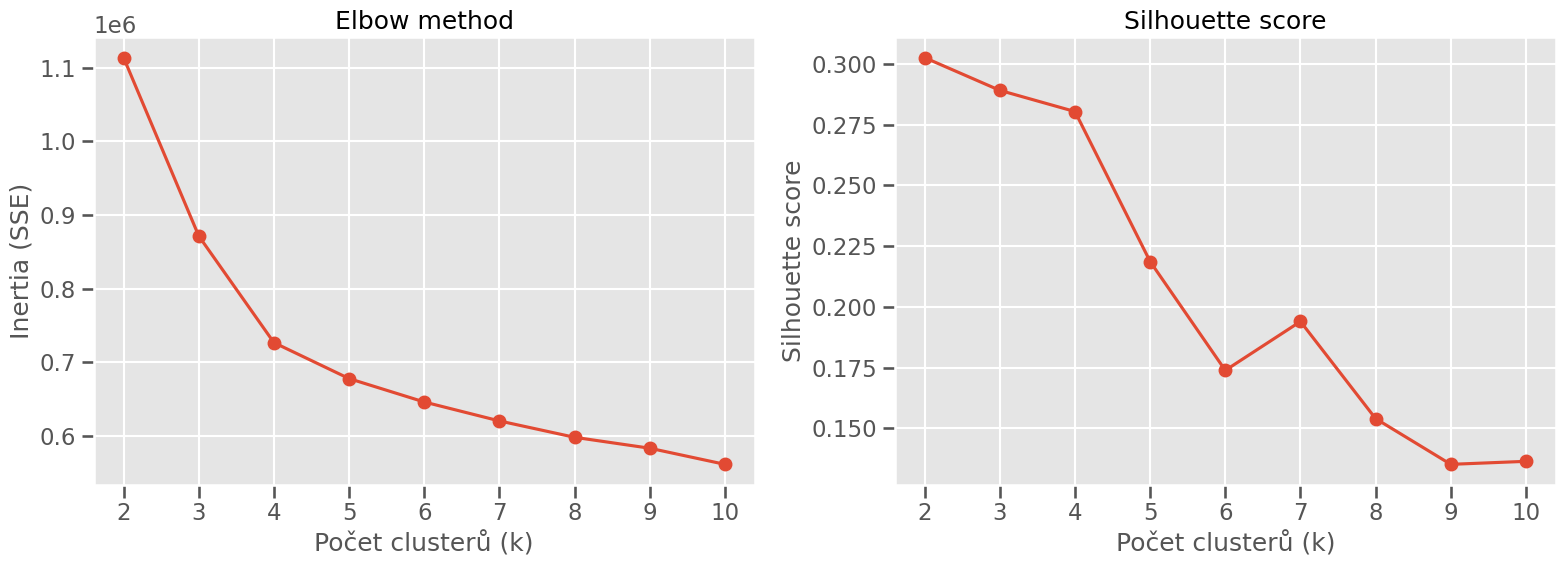

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_test = kmeans_test.fit_predict(X_scaled)

    inertias.append(kmeans_test.inertia_)

    sil = silhouette_score(X_scaled, labels_test)
    silhouettes.append(sil)
    print(f"k={k}, silhouette={sil:.4f}")

# Ploty vedle sebe
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Elbow
ax[0].plot(K_range, inertias, marker='o')
ax[0].set_title("Elbow method")
ax[0].set_xlabel("Počet clusterů (k)")
ax[0].set_ylabel("Inertia (SSE)")

# Silhouette
ax[1].plot(K_range, silhouettes, marker='o')
ax[1].set_title("Silhouette score")
ax[1].set_xlabel("Počet clusterů (k)")
ax[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()


In [23]:
from sklearn.cluster import KMeans

k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

labels[:10]


array([2, 3, 2, 2, 3, 0, 2, 2, 3, 1], dtype=int32)

In [24]:
df_num["cluster"] = labels
df_num.head()


,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,display_size_in,refresh_hz,battery_wh,charger_watts,psu_watts,weight_kg,warranty_months,price,cluster,distance_from_center
0,3,12,24,2.8,3.8,2.0,6.0,16.0,1024.0,1.0,27.0,90.0,0.0,0.0,750.0,11.00,36.0,1383.99,2,2.414535
1,4,12,24,2.6,3.6,4.0,10.0,64.0,512.0,1.0,16.0,90.0,56.0,120.0,0.0,2.03,12.0,2274.99,3,2.653156
2,2,8,16,2.6,3.6,1.0,4.0,8.0,512.0,2.0,32.0,120.0,0.0,0.0,850.0,7.00,24.0,1879.99,2,1.945448
3,2,6,12,2.6,3.6,2.0,6.0,16.0,512.0,2.0,27.0,120.0,0.0,0.0,650.0,6.00,36.0,1331.99,2,2.050582
4,5,16,32,2.8,3.9,5.0,12.0,96.0,256.0,1.0,15.6,90.0,80.0,90.0,0.0,1.50,12.0,2681.99,3,2.108568


In [25]:
import numpy as np

centers = kmeans.cluster_centers_

# vypočítáme vzdálenost každého řádku od jeho clusterového centra
distances = np.linalg.norm(X_scaled - centers[labels], axis=1)

df_num["distance_from_center"] = distances
df_num[["price", "cluster", "distance_from_center"]].head()

,price,cluster,distance_from_center
0,1383.99,2,2.643238
1,2274.99,3,1.718444
2,1879.99,2,1.534685
3,1331.99,2,1.724801
4,2681.99,3,2.167528


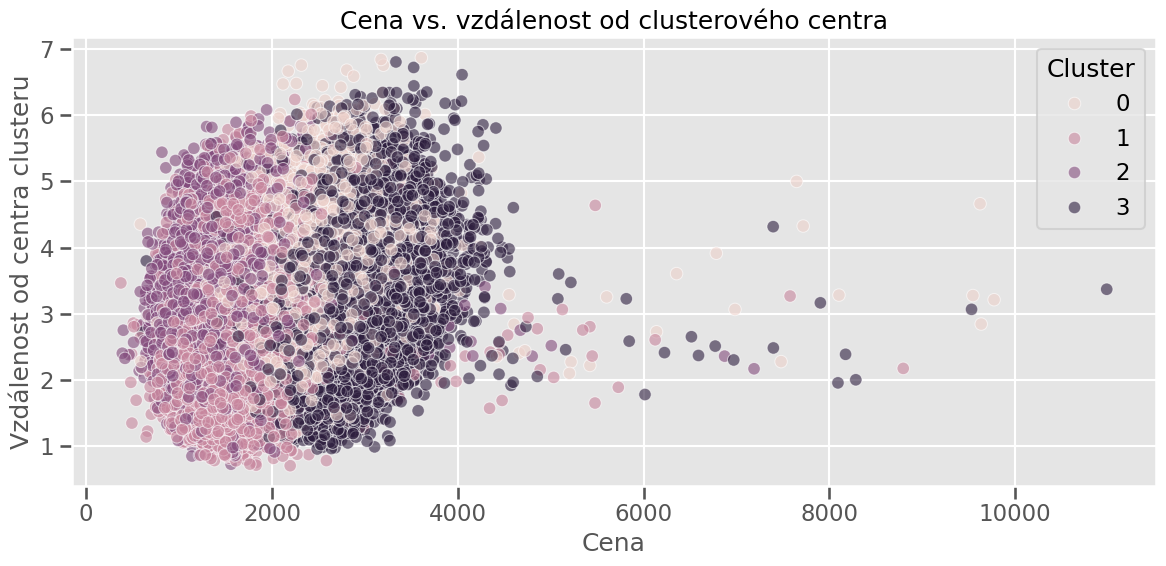

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_num,
    x="price",
    y="distance_from_center",
    hue="cluster",
    alpha=0.6
)

plt.title("Cena vs. vzdálenost od clusterového centra")
plt.xlabel("Cena")
plt.ylabel("Vzdálenost od centra clusteru")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


In [28]:
# hranice 99. percentilu vzdálenosti
threshold = df_num["distance_from_center"].quantile(0.99)

anomalies = df_num[df_num["distance_from_center"] >= threshold].copy()
anomalies_sorted = anomalies.sort_values("distance_from_center", ascending=False)

anomalies_sorted.head(20)


,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,display_size_in,refresh_hz,battery_wh,charger_watts,psu_watts,weight_kg,warranty_months,price,cluster,distance_from_center
7869,6,28,28,3.4,4.3,6.0,2.0,136.0,4096.0,1.0,24.0,240.0,0.0,0.0,750.0,11.00,36.0,3607.99,0,6.868127
20640,6,28,56,3.4,4.2,6.0,16.0,128.0,4096.0,1.0,27.0,120.0,0.0,0.0,850.0,16.00,12.0,3173.99,0,6.841834
34327,6,24,48,3.0,4.0,6.0,16.0,128.0,4096.0,2.0,14.0,165.0,60.0,45.0,0.0,1.57,48.0,3333.99,3,6.804355
50938,6,28,56,3.4,4.4,6.0,0.0,128.0,4096.0,2.0,34.0,120.0,0.0,0.0,1000.0,13.00,12.0,2315.99,0,6.756507
6237,6,28,56,3.4,4.5,6.0,16.0,128.0,4096.0,1.0,34.0,120.0,0.0,0.0,1000.0,9.00,12.0,3198.99,0,6.755290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40142,4,14,28,3.0,3.9,4.0,10.0,64.0,4096.0,4.0,24.0,60.0,0.0,0.0,750.0,9.00,12.0,2958.99,0,5.111557
13162,6,26,52,3.4,4.5,6.0,16.0,128.0,256.0,1.0,27.0,165.0,0.0,0.0,550.0,8.00,12.0,2654.99,0,5.111537
18793,3,10,10,2.8,3.7,4.0,2.0,32.0,4096.0,1.0,24.0,60.0,0.0,0.0,300.0,12.00,12.0,1896.99,2,5.111434
63166,5,16,16,2.8,3.8,5.0,6.0,96.0,4096.0,1.0,13.3,60.0,90.0,240.0,0.0,1.32,24.0,3064.99,3,5.111344


In [29]:
cluster_medians = df_num.groupby("cluster")["price"].median()
cluster_medians

,price
cluster,
0,2211.99
1,1650.99
2,1522.99
3,2452.99


In [30]:
# funkce pro výpočet rozdílu od mediánu clusteru
df_num["price_deviation"] = df_num.apply(
    lambda row: row["price"] - cluster_medians[row["cluster"]],
    axis=1
)

df_num[["cluster", "price", "price_deviation"]].head()

,cluster,price,price_deviation
0,2,1383.99,-139.0
1,3,2274.99,-178.0
2,2,1879.99,357.0
3,2,1331.99,-191.0
4,3,2681.99,229.0


In [31]:
top_overpriced = (
    df_num.sort_values("price_deviation", ascending=False)
    .groupby("cluster")
    .head(10)
)

top_underpriced = (
    df_num.sort_values("price_deviation")
    .groupby("cluster")
    .head(10)
)

top_overpriced.head(), top_underpriced.head()

(       cpu_tier  cpu_cores  cpu_threads  cpu_base_ghz  cpu_boost_ghz  \
 40823         5         16           32           2.8            3.7   
 54591         4         14           14           3.0            4.0   
 64831         5         16           32           3.2            4.1   
 75607         4         14           28           3.0            3.9   
 69792         5         20           20           3.2            4.2   
 
        gpu_tier  vram_gb  ram_gb  storage_gb  storage_drive_count  ...  \
 40823       6.0     16.0    96.0      2048.0                  1.0  ...   
 54591       5.0      4.0    64.0      1024.0                  1.0  ...   
 64831       5.0      2.0    96.0      2048.0                  2.0  ...   
 75607       4.0      4.0    64.0      4096.0                  2.0  ...   
 69792       4.0      2.0    64.0      2048.0                  1.0  ...   
 
        refresh_hz  battery_wh  charger_watts  psu_watts  weight_kg  \
 40823       120.0        60.0       

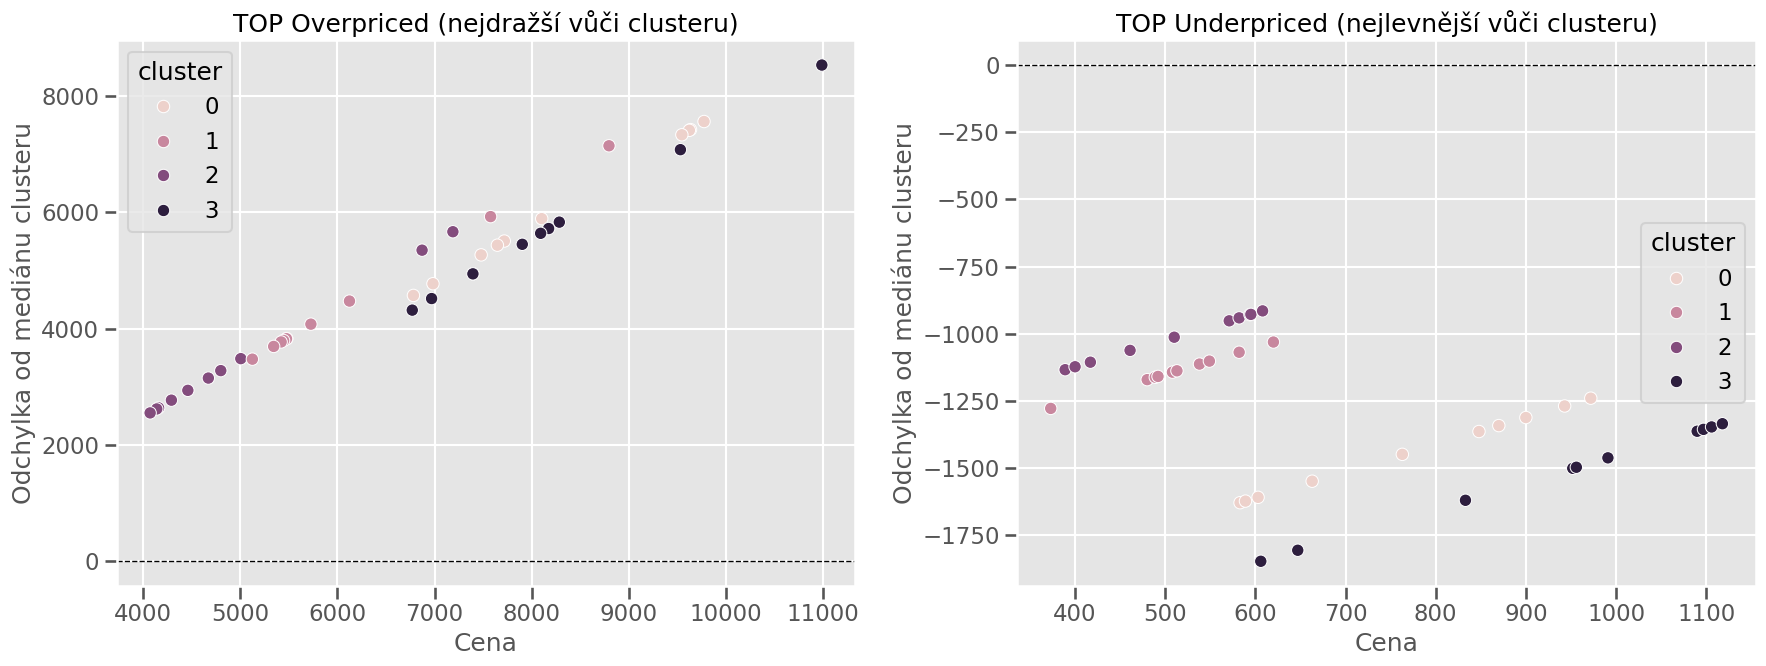

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Overpriced ---
sns.scatterplot(
    data=top_overpriced,
    x="price",
    y="price_deviation",
    hue="cluster",
    ax=axes[0],
    s=80
)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("TOP Overpriced (nejdražší vůči clusteru)")
axes[0].set_xlabel("Cena")
axes[0].set_ylabel("Odchylka od mediánu clusteru")

# --- Underpriced ---
sns.scatterplot(
    data=top_underpriced,
    x="price",
    y="price_deviation",
    hue="cluster",
    ax=axes[1],
    s=80
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("TOP Underpriced (nejlevnější vůči clusteru)")
axes[1].set_xlabel("Cena")
axes[1].set_ylabel("Odchylka od mediánu clusteru")

plt.tight_layout()
plt.show()


In [33]:
from sklearn.decomposition import PCA

# PCA na 2 komponenty
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# uložíme do dataframe
df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": df_num["cluster"],
    "price_deviation": df_num["price_deviation"],
    "price": df_num["price"]
})

df_pca.head()

,PC1,PC2,cluster,price_deviation,price
0,1.475623,-2.224728,2,-139.0,1383.99
1,0.357064,2.136847,3,-178.0,2274.99
2,0.140133,-3.413779,2,357.0,1879.99
3,-0.060273,-2.768988,2,-191.0,1331.99
4,2.114719,3.354668,3,229.0,2681.99


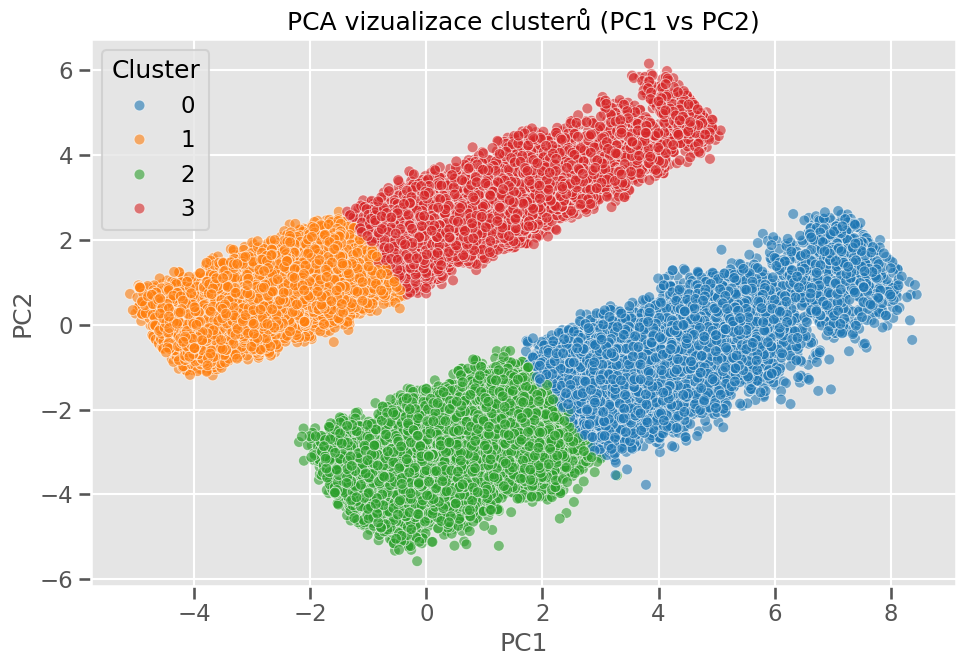

In [34]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    alpha=0.6,
    s=60
)

plt.title("PCA vizualizace clusterů (PC1 vs PC2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


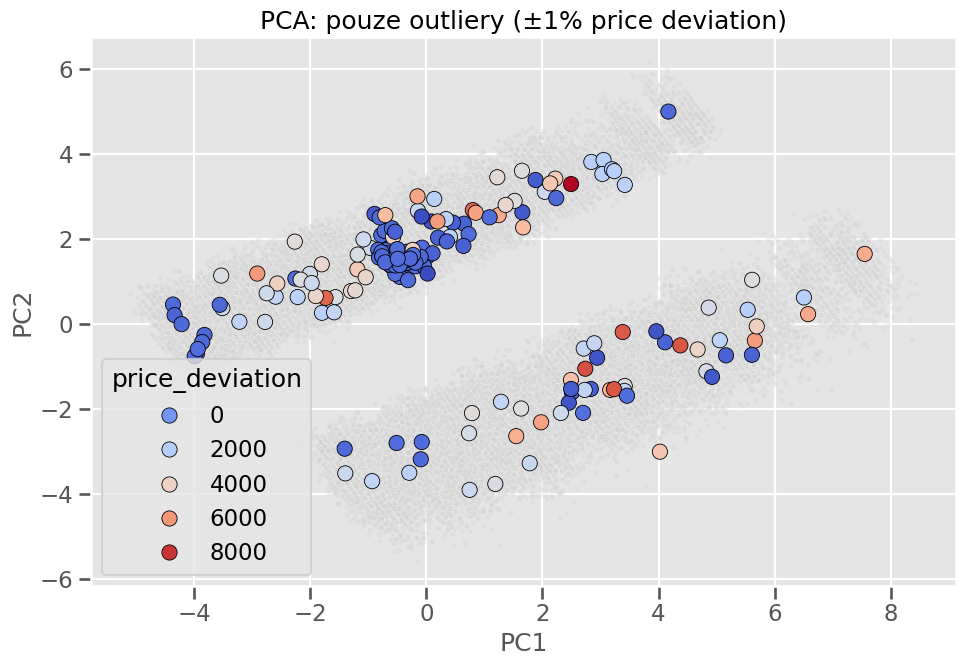

In [38]:
# hranice pro nahoře/dole 1 %
upper_thr = df_num["price_deviation"].quantile(0.999)
lower_thr = df_num["price_deviation"].quantile(0.001)

df_pca["is_outlier"] = (
    (df_num["price_deviation"] >= upper_thr) |
    (df_num["price_deviation"] <= lower_thr)
)

outliers = df_pca[df_pca["is_outlier"]]

plt.figure(figsize=(10, 7))

# vykreslíme nejprve všechny body šedě
sns.scatterplot(
    data=df_pca,
    x="PC1", y="PC2",
    color="lightgray",
    alpha=0.3,
    s=20
)

# teď vykreslíme OUTLIERY barevně
sns.scatterplot(
    data=outliers,
    x="PC1", y="PC2",
    hue="price_deviation",
    palette="coolwarm",
    s=120,
    edgecolor="black",
    linewidth=0.6
)

plt.title("PCA: pouze outliery (±1% price deviation)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


tady jsem cekal ze budou na okraji clusteru ale jsou spise uprostred

In [50]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',   # full = nejflexibilnější elipsy
    random_state=42
)

gmm_labels = gmm.fit_predict(X_scaled)


In [51]:
df_pca_gmm = df_pca.copy()
df_pca_gmm["gmm_cluster"] = gmm_labels
df_pca_gmm.head()


,PC1,PC2,cluster,price_deviation,price,is_outlier,gmm_cluster
0,1.475623,-2.224728,2,-139.0,1383.99,False,0
1,0.357064,2.136847,3,-178.0,2274.99,False,1
2,0.140133,-3.413779,2,357.0,1879.99,False,0
3,-0.060273,-2.768988,2,-191.0,1331.99,False,0
4,2.114719,3.354668,3,229.0,2681.99,False,1


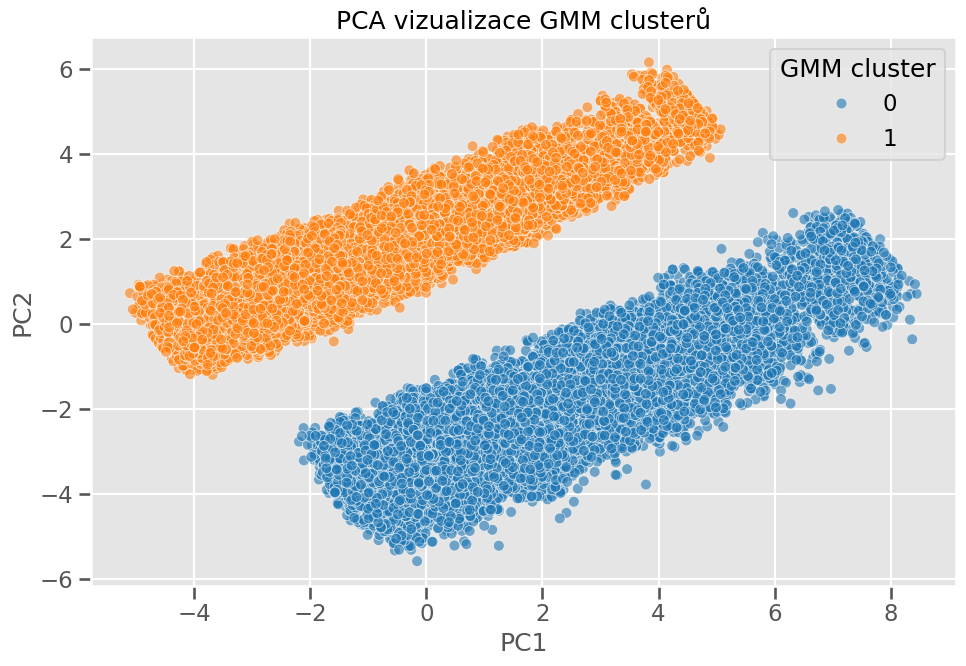

In [52]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_pca_gmm,
    x="PC1",
    y="PC2",
    hue="gmm_cluster",
    palette="tab10",
    alpha=0.6,
    s=60
)

plt.title("PCA vizualizace GMM clusterů")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="GMM cluster")
plt.tight_layout()
plt.show()


In [49]:
df_clusters = df_num.copy()
df_clusters["device_type"] = df.loc[df_num.index, "device_type"]

cluster_device_counts = (
    df_clusters
    .groupby(["cluster", "device_type"])
    .size()
    .unstack(fill_value=0)
)

cluster_device_counts

device_type,Desktop,Laptop
cluster,,
0,14273,0
1,0,33988
2,22969,0
3,0,21511


NOvy zacatek

In [53]:
df_desktop = df[df["device_type"] == "Desktop"].copy()
df_desktop.shape


(37242, 33)

In [54]:
features = [
    "cpu_tier",
    "cpu_cores",
    "cpu_threads",
    "cpu_base_ghz",
    "cpu_boost_ghz",
    "gpu_tier",
    "vram_gb",
    "ram_gb",
    "storage_gb",
    "storage_drive_count",
    "psu_watts",
    "weight_kg",
    "price"
]

df_desktop_num = df_desktop[features].dropna().copy()
df_desktop_num.shape


(37242, 13)

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = df_desktop_num.drop(columns=["price"])
y_price = df_desktop_num["price"]

X_scaled = scaler.fit_transform(X)


k=2, silhouette=0.3327
k=3, silhouette=0.2123
k=4, silhouette=0.1570
k=5, silhouette=0.1584
k=6, silhouette=0.1628
k=7, silhouette=0.1634
k=8, silhouette=0.1562
k=9, silhouette=0.1586
k=10, silhouette=0.1478


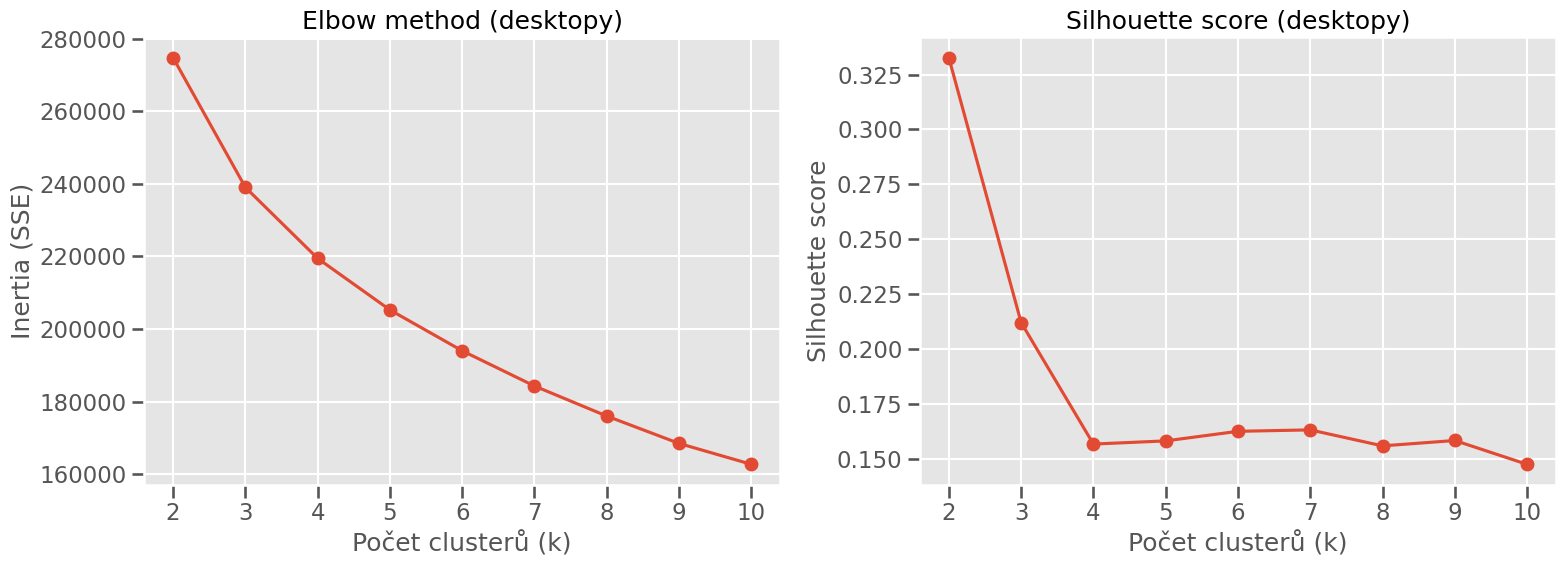

In [56]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_test = kmeans_test.fit_predict(X_scaled)

    inertias.append(kmeans_test.inertia_)

    sil = silhouette_score(X_scaled, labels_test)
    silhouettes.append(sil)
    print(f"k={k}, silhouette={sil:.4f}")

# Ploty
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Elbow
ax[0].plot(K_range, inertias, marker='o')
ax[0].set_title("Elbow method (desktopy)")
ax[0].set_xlabel("Počet clusterů (k)")
ax[0].set_ylabel("Inertia (SSE)")

# Silhouette
ax[1].plot(K_range, silhouettes, marker='o')
ax[1].set_title("Silhouette score (desktopy)")
ax[1].set_xlabel("Počet clusterů (k)")
ax[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()


In [57]:
from sklearn.cluster import KMeans

k = 3
kmeans_desktop = KMeans(n_clusters=k, random_state=42, n_init=10)
desktop_labels = kmeans_desktop.fit_predict(X_scaled)

desktop_labels[:10]


array([2, 0, 0, 1, 0, 2, 0, 2, 2, 0], dtype=int32)

In [58]:
from sklearn.decomposition import PCA

# PCA na 2 komponenty
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_desktop_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": desktop_labels,
    "price": y_price.values
})

df_desktop_pca.head()


,PC1,PC2,cluster,price
0,-0.386959,0.889386,2,1383.99
1,-2.216633,0.354628,0,1879.99
2,-2.068737,-0.620026,0,1331.99
3,4.329276,1.319489,1,2751.99
4,-3.037176,0.761722,0,1609.99


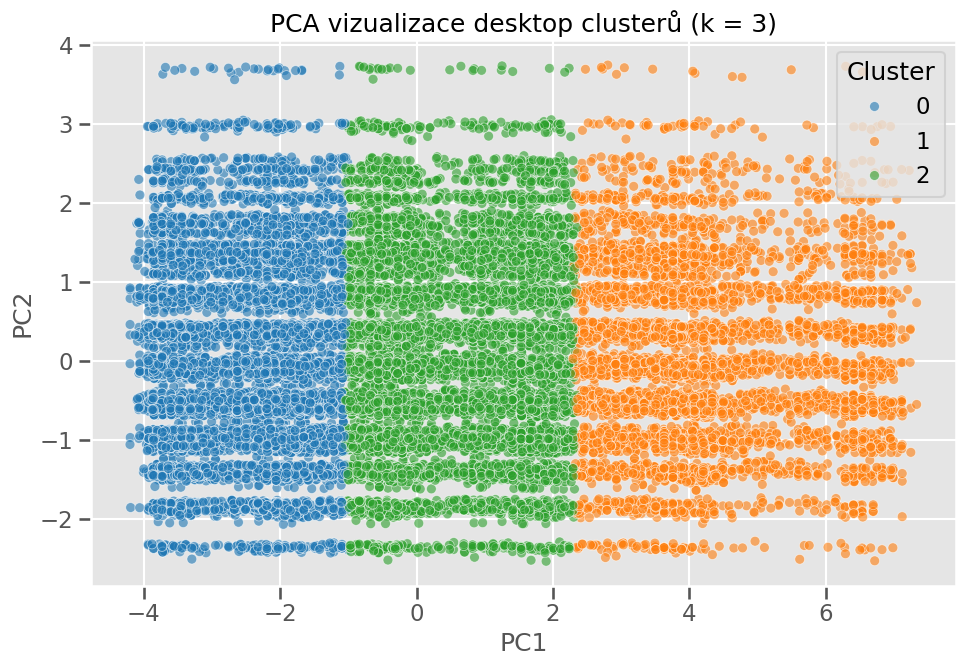

In [59]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_desktop_pca,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    alpha=0.6,
    s=50
)

plt.title("PCA vizualizace desktop clusterů (k = 3)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


In [60]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=42
)

gmm_labels = gmm.fit_predict(X_scaled)


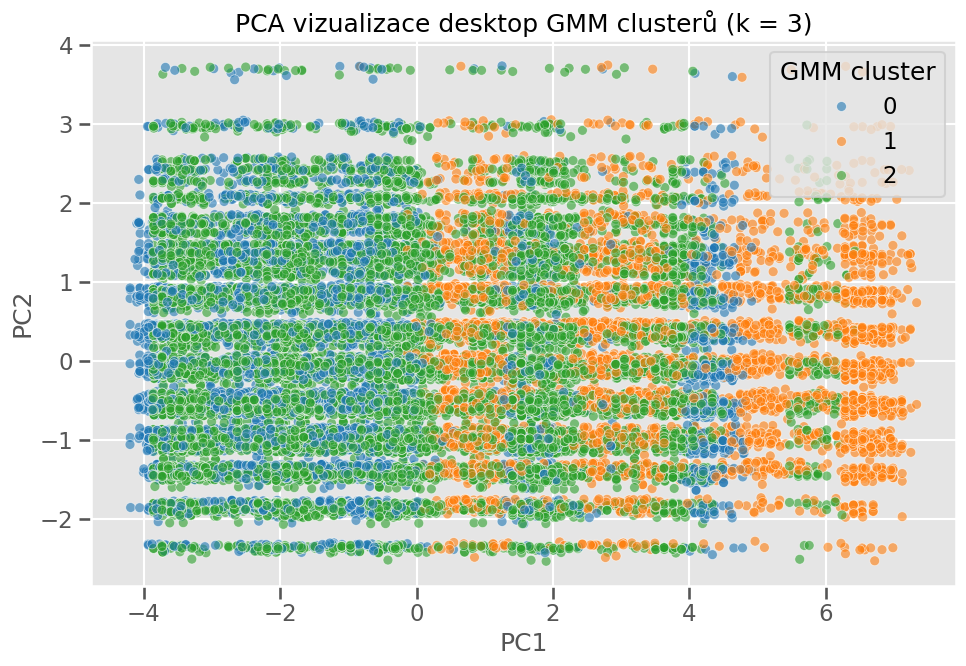

In [61]:
df_desktop_pca_gmm = df_desktop_pca.copy()
df_desktop_pca_gmm["gmm_cluster"] = gmm_labels

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_desktop_pca_gmm,
    x="PC1",
    y="PC2",
    hue="gmm_cluster",
    palette="tab10",
    alpha=0.6,
    s=50
)

plt.title("PCA vizualizace desktop GMM clusterů (k = 3)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="GMM cluster")
plt.tight_layout()
plt.show()


In [62]:
cluster_medians = df_desktop_num.assign(cluster=gmm_labels).groupby("cluster")["price"].median()
cluster_medians


,price
cluster,
0,1680.49
1,2409.99
2,1677.99


In [63]:
df_desktop_num["cluster"] = gmm_labels

df_desktop_num["price_deviation"] = df_desktop_num.apply(
    lambda row: row["price"] - cluster_medians[row["cluster"]],
    axis=1
)

df_desktop_num[["cluster", "price", "price_deviation"]].head()


,cluster,price,price_deviation
0,2,1383.99,-294.0
2,2,1879.99,202.0
3,2,1331.99,-346.0
5,0,2751.99,1071.5
6,0,1609.99,-70.5


In [64]:
# nejdražší oproti své výkonové třídě
top_over = (
    df_desktop_num.sort_values("price_deviation", ascending=False)
    .groupby("cluster")
    .head(10)
)

# nejlevnější oproti své výkonové třídě
top_under = (
    df_desktop_num.sort_values("price_deviation", ascending=True)
    .groupby("cluster")
    .head(10)
)

top_over.head(), top_under.head()


(       cpu_tier  cpu_cores  cpu_threads  cpu_base_ghz  cpu_boost_ghz  \
 75607         4         14           28           3.0            3.9   
 54591         4         14           14           3.0            4.0   
 64831         5         16           32           3.2            4.1   
 69792         5         20           20           3.2            4.2   
 41921         5         20           40           3.2            4.1   
 
        gpu_tier  vram_gb  ram_gb  storage_gb  storage_drive_count  psu_watts  \
 75607       4.0      4.0    64.0      4096.0                  2.0      650.0   
 54591       5.0      4.0    64.0      1024.0                  1.0      550.0   
 64831       5.0      2.0    96.0      2048.0                  2.0      450.0   
 69792       4.0      2.0    64.0      2048.0                  1.0      550.0   
 41921       5.0     12.0    96.0      1024.0                  4.0      550.0   
 
        weight_kg    price  cluster  price_deviation  
 75607        8.0

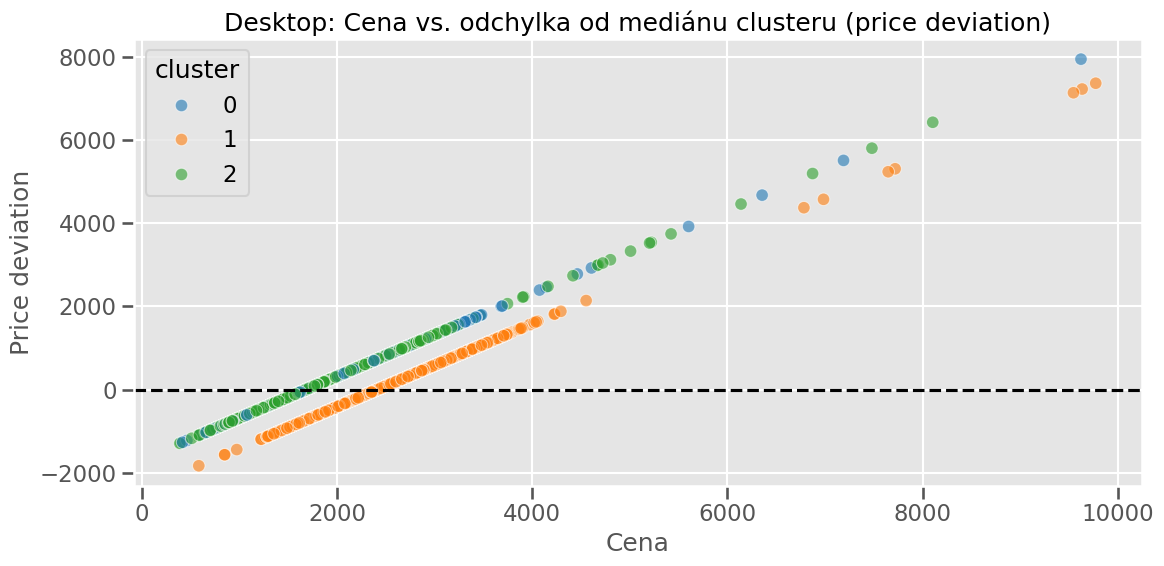

In [65]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df_desktop_num,
    x="price",
    y="price_deviation",
    hue="cluster",
    palette="tab10",
    alpha=0.6
)

plt.axhline(0, color="black", linestyle="--")
plt.title("Desktop: Cena vs. odchylka od mediánu clusteru (price deviation)")
plt.xlabel("Cena")
plt.ylabel("Price deviation")
plt.tight_layout()
plt.show()


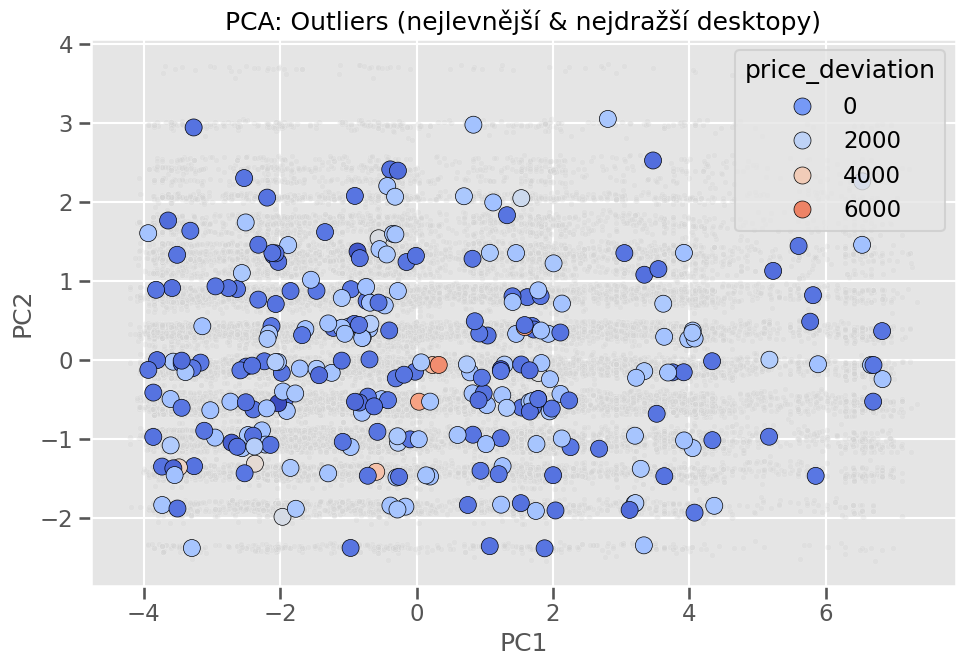

In [66]:
# hranice pro extrémy
upper_thr = df_desktop_num["price_deviation"].quantile(0.99)
lower_thr = df_desktop_num["price_deviation"].quantile(0.01)

df_outliers = df_desktop_num[(df_desktop_num["price_deviation"] >= upper_thr) |
                             (df_desktop_num["price_deviation"] <= lower_thr)]

# přidáme PCA souřadnice
df_outliers = df_outliers.join(df_desktop_pca[["PC1", "PC2"]])

plt.figure(figsize=(10, 7))

# šedé pozadí = všechny desktopy
sns.scatterplot(
    data=df_desktop_pca,
    x="PC1",
    y="PC2",
    color="lightgray",
    alpha=0.3,
    s=20
)

# outliery barevně
sns.scatterplot(
    data=df_outliers,
    x="PC1",
    y="PC2",
    hue="price_deviation",
    palette="coolwarm",
    s=150,
    edgecolor="black",
    linewidth=0.5
)

plt.title("PCA: Outliers (nejlevnější & nejdražší desktopy)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


In [67]:
# přidáme zpět identifikační sloupce
df_desktop_full = df_desktop.loc[df_desktop_num.index].copy()
df_desktop_full["cluster"] = df_desktop_num["cluster"]
df_desktop_full["price_deviation"] = df_desktop_num["price_deviation"]

# TOP 20 nejdražší oproti clusteru
top20_overall_over = df_desktop_full.sort_values("price_deviation", ascending=False).head(20)

# TOP 20 nejlevnější oproti clusteru
top20_overall_under = df_desktop_full.sort_values("price_deviation", ascending=True).head(20)

print("=== TOP 20 OVERPRICED DESKTOPS ===")
display(top20_overall_over[[
    "brand", "model", "price", "price_deviation", "cluster",
    "cpu_model", "cpu_cores", "gpu_model", "vram_gb", "ram_gb", "storage_gb"
]])

print("\n=== TOP 20 UNDERPRICED DESKTOPS ===")
display(top20_overall_under[[
    "brand", "model", "price", "price_deviation", "cluster",
    "cpu_model", "cpu_cores", "gpu_model", "vram_gb", "ram_gb", "storage_gb"
]])


=== TOP 20 OVERPRICED DESKTOPS ===


,brand,model,price,price_deviation,cluster,cpu_model,cpu_cores,gpu_model,vram_gb,ram_gb,storage_gb
75607,MSI,MSI Pro 8M3,9621.99,7941.5,0,Intel i7-14439,14,Apple Integrated,4.0,64.0,4096.0
54591,Apple,Apple Pro XVG,9772.99,7363.0,1,Apple M1 Pro,14,Apple Integrated,4.0,64.0,1024.0
64831,HP,HP Think 1FC,9633.99,7224.0,1,AMD Ryzen 7 7131,16,Arc A770,2.0,96.0,2048.0
69792,Apple,Apple Station N4Y,9544.99,7135.0,1,Apple M2 Max,20,Apple Integrated,2.0,64.0,2048.0
41921,ASUS,ASUS Pro 6RY,8102.99,6425.0,2,AMD Ryzen 7 6835,20,RTX 40 80 Ti,12.0,96.0,1024.0
20325,Razer,Razer Station X09,7479.99,5802.0,2,Intel i7-11511,12,RX 6000 80,10.0,64.0,512.0
64574,Razer,Razer Arena YN3,7188.99,5508.5,0,AMD Ryzen 5 5169,10,Arc A700,6.0,32.0,512.0
2855,Apple,Apple Station VXJ,7717.99,5308.0,1,Apple M3 Max,28,Apple Integrated,2.0,136.0,512.0
33543,Acer,Acer Strix B8R,7646.99,5237.0,1,Intel i9-10539,26,RX 6000 90,16.0,128.0,2048.0
38807,MSI,MSI Station KLY,6871.99,5194.0,2,Intel i5-11545,8,RX 7000 70,8.0,32.0,512.0



=== TOP 20 UNDERPRICED DESKTOPS ===


,brand,model,price,price_deviation,cluster,cpu_model,cpu_cores,gpu_model,vram_gb,ram_gb,storage_gb
12660,HP,HP Cube FIR,582.99,-1827.0,1,AMD Ryzen 7 5246,12,Arc A580,6.0,32.0,512.0
24197,ASUS,ASUS Think 3Y2,847.99,-1562.0,1,Intel i7-14728,12,Apple Integrated,0.0,32.0,512.0
5120,ASUS,ASUS Pro 353,847.99,-1562.0,1,Intel i7-11309,12,Apple Integrated,2.0,64.0,1024.0
11004,Apple,Apple Think LPE,971.99,-1438.0,1,Apple M2,12,Apple Integrated,6.0,64.0,512.0
55423,Razer,Razer Strix Y30,388.99,-1289.0,2,AMD Ryzen 5 6939,8,RTX 30 50,4.0,8.0,512.0
26799,MSI,MSI Pro K4E,399.99,-1278.0,2,Intel i3-13480,4,RTX 40 60,6.0,8.0,1024.0
62116,Dell,Dell Strix VCU,416.99,-1263.5,0,AMD Ryzen 5 7272,8,Apple Integrated,0.0,16.0,256.0
49924,Samsung,Samsung Cube 2JV,460.99,-1219.5,0,AMD Ryzen 5 3687,8,RX 6000 50,4.0,8.0,256.0
66989,ASUS,ASUS Station UBL,1220.99,-1189.0,1,Intel i7-13993,12,Arc A580,0.0,32.0,1024.0
37766,HP,HP Creator K8J,1222.99,-1187.0,1,Intel i7-13672,14,RX 7000 70,8.0,32.0,256.0


In [68]:
from sklearn.feature_selection import f_classif
import pandas as pd

# všechny numerické featury kromě price
features_for_f = [
    "cpu_tier", "cpu_cores", "cpu_threads",
    "cpu_base_ghz", "cpu_boost_ghz",
    "gpu_tier", "vram_gb",
    "ram_gb", "storage_gb",
    "storage_drive_count", "psu_watts", "weight_kg"
]

X_f = df_desktop_num[features_for_f]
y_f = df_desktop_num["cluster"]

F, p = f_classif(X_f, y_f)

feature_importance = pd.DataFrame({
    "feature": features_for_f,
    "F_score": F
}).sort_values("F_score", ascending=False)

feature_importance


,feature,F_score
1,cpu_cores,9488.544567
7,ram_gb,8576.827805
3,cpu_base_ghz,7513.044285
0,cpu_tier,7513.044285
4,cpu_boost_ghz,6327.912609
5,gpu_tier,4974.659952
6,vram_gb,3772.264784
2,cpu_threads,3221.914345
11,weight_kg,1.583744
8,storage_gb,0.450521


In [69]:
cluster_summary = df_desktop_num.groupby("cluster")[features_for_f + ["price"]].mean()
cluster_summary


,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,psu_watts,weight_kg,price
cluster,,,,,,,,,,,,,
0,2.698836,8.960255,15.582345,2.739767,3.679194,2.895477,4.297321,31.709267,898.079930,2.041612,679.770531,8.258893,1729.269754
1,4.918568,17.881284,28.030792,3.183714,4.120738,4.788536,4.329809,86.220738,910.127249,2.045261,678.946392,8.348173,2428.231885
2,2.896056,9.720002,19.440004,2.779211,3.719619,2.881458,7.762916,34.842545,900.204195,2.047795,678.250451,8.274986,1709.877966


In [70]:
df_desktop_num["cluster"].value_counts().sort_index()


,count
cluster,
0,9108
1,5391
2,22743


In [73]:
df_desktop_num.head(20)

,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,psu_watts,weight_kg,price,cluster,price_deviation
0,3,12,24,2.8,3.8,2.0,6.0,16.0,1024.0,1.0,750.0,11.0,1383.99,2,-294.0
2,2,8,16,2.6,3.6,1.0,4.0,8.0,512.0,2.0,850.0,7.0,1879.99,2,202.0
3,2,6,12,2.6,3.6,2.0,6.0,16.0,512.0,2.0,650.0,6.0,1331.99,2,-346.0
5,5,16,32,3.2,4.3,6.0,16.0,96.0,512.0,2.0,1000.0,9.0,2751.99,0,1071.5
6,2,6,6,2.6,3.5,1.0,0.0,8.0,2048.0,2.0,850.0,9.0,1609.99,0,-70.5
7,3,8,8,2.8,3.7,4.0,0.0,32.0,1024.0,1.0,650.0,8.0,2139.99,0,459.5
11,2,6,10,2.6,3.6,2.0,6.0,16.0,1024.0,3.0,750.0,11.0,1366.99,0,-313.5
12,4,14,28,3.0,3.9,4.0,10.0,64.0,512.0,1.0,1200.0,13.0,1507.99,2,-170.0
13,4,12,24,3.0,3.9,4.0,10.0,64.0,1024.0,1.0,550.0,6.0,2761.99,2,1084.0
18,2,8,16,2.6,3.5,2.0,6.0,16.0,1024.0,2.0,550.0,8.0,1388.99,2,-289.0


In [74]:
# vytvoříme dataframe, kde jsou i značky i numerika
df_desktop_clusters = df_desktop.loc[df_desktop_num.index].copy()

# přidáme cluster a price deviation
df_desktop_clusters["cluster"] = df_desktop_num["cluster"]
df_desktop_clusters["price_deviation"] = df_desktop_num["price_deviation"]

df_desktop_clusters.head()


,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,...,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price,cluster,price_deviation
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,...,0.0,0.0,750.0,Wi-Fi 6,5.1,11.0,36.0,1383.99,2,-294.0
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,...,0.0,0.0,850.0,Wi-Fi 6,5.0,7.0,24.0,1879.99,2,202.0
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,...,0.0,0.0,650.0,Wi-Fi 6,5.2,6.0,36.0,1331.99,2,-346.0
5,Desktop,MSI,MSI Think KSG,2025,Windows,ATX,Intel,Intel i7-10369,5,16,...,0.0,0.0,1000.0,Wi-Fi 5,5.0,9.0,36.0,2751.99,0,1071.5
6,Desktop,Apple,Apple Arena R5Q,2024,Windows,ATX,Apple,Apple M2,2,6,...,0.0,0.0,850.0,Wi-Fi 6,5.1,9.0,24.0,1609.99,0,-70.5


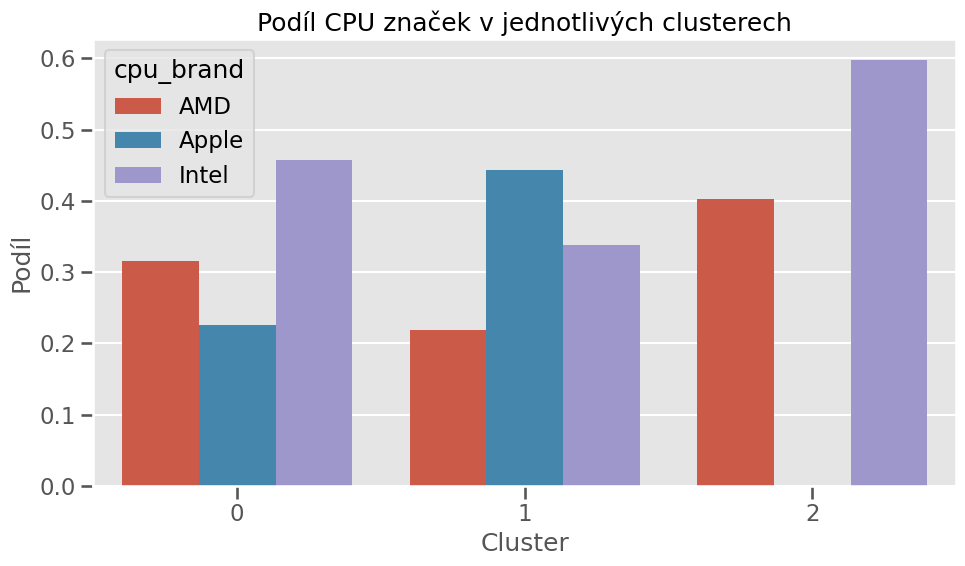

In [80]:
# Calculate the counts of each cpu_brand within each cluster
brand_counts = df_desktop_clusters.groupby(["cluster", "cpu_brand"]).size()

# Calculate the sum of counts for each cluster
cluster_sums = brand_counts.groupby(level='cluster').transform('sum')

# Calculate the share
cpu_brand_share_series = brand_counts / cluster_sums

# Convert the MultiIndex Series to a DataFrame and name the value column
cpu_brand_share = cpu_brand_share_series.reset_index(name='share')

plt.figure(figsize=(10, 6))
sns.barplot(
    data=cpu_brand_share,
    x="cluster",
    y="share",
    hue="cpu_brand"
)
plt.title("Podíl CPU značek v jednotlivých clusterech")
plt.xlabel("Cluster")
plt.ylabel("Podíl")
plt.tight_layout()
plt.show()

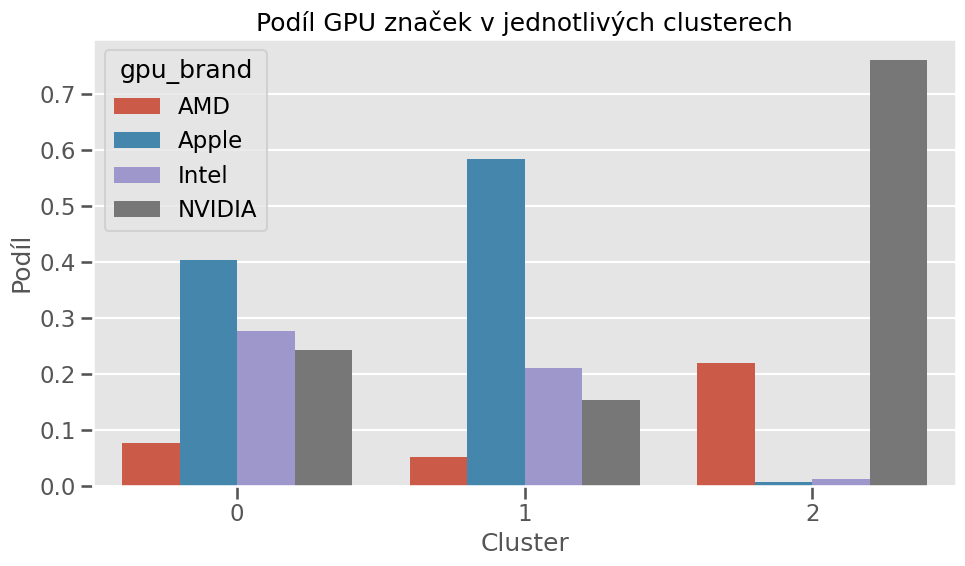

In [81]:
# Counts pro GPU značku
gpu_brand_counts = df_desktop_clusters.groupby(["cluster", "gpu_brand"]).size()

# Sumy v rámci clusteru
gpu_cluster_sums = gpu_brand_counts.groupby(level='cluster').transform('sum')

# Podíly
gpu_brand_share = (gpu_brand_counts / gpu_cluster_sums).reset_index(name='share')

plt.figure(figsize=(10, 6))
sns.barplot(
    data=gpu_brand_share,
    x="cluster",
    y="share",
    hue="gpu_brand"
)
plt.title("Podíl GPU značek v jednotlivých clusterech")
plt.xlabel("Cluster")
plt.ylabel("Podíl")
plt.tight_layout()
plt.show()


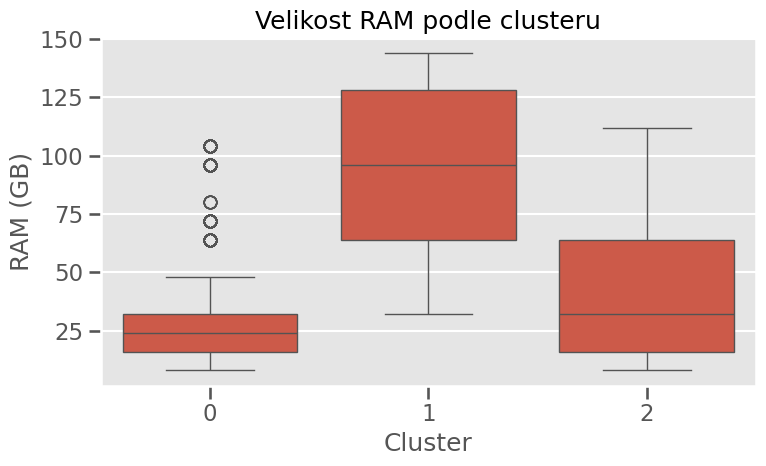

In [82]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_desktop_clusters,
    x="cluster",
    y="ram_gb"
)
plt.title("Velikost RAM podle clusteru")
plt.xlabel("Cluster")
plt.ylabel("RAM (GB)")
plt.tight_layout()
plt.show()


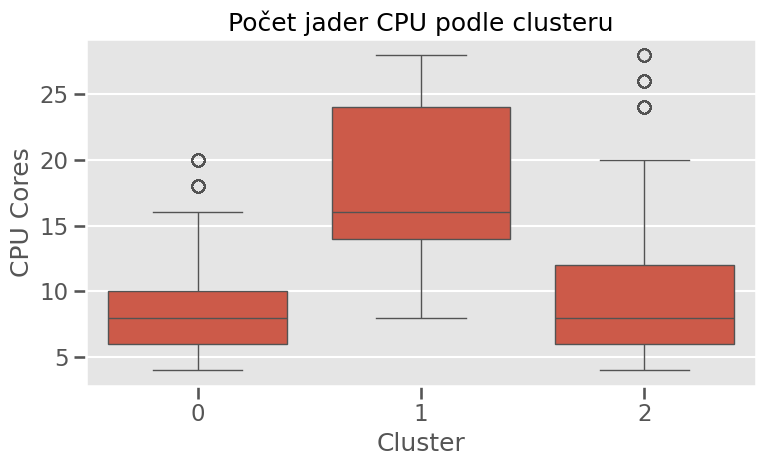

In [83]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_desktop_clusters,
    x="cluster",
    y="cpu_cores"
)
plt.title("Počet jader CPU podle clusteru")
plt.xlabel("Cluster")
plt.ylabel("CPU Cores")
plt.tight_layout()
plt.show()


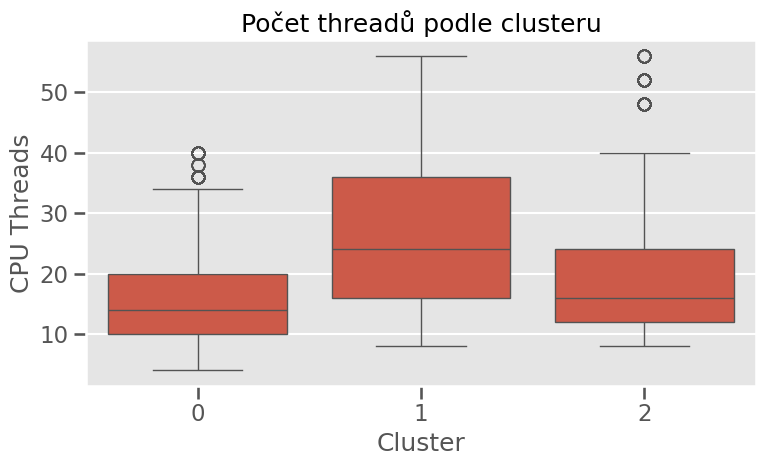

In [84]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_desktop_clusters,
    x="cluster",
    y="cpu_threads"
)
plt.title("Počet threadů podle clusteru")
plt.xlabel("Cluster")
plt.ylabel("CPU Threads")
plt.tight_layout()
plt.show()


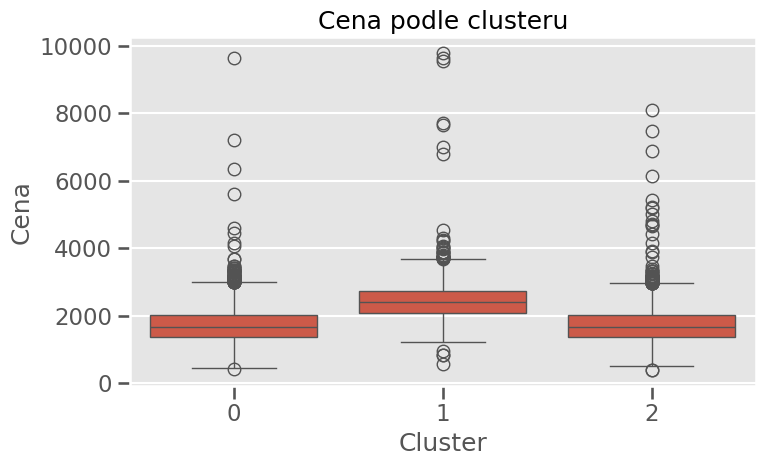

In [85]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_desktop_clusters,
    x="cluster",
    y="price"
)
plt.title("Cena podle clusteru")
plt.xlabel("Cluster")
plt.ylabel("Cena")
plt.tight_layout()
plt.show()


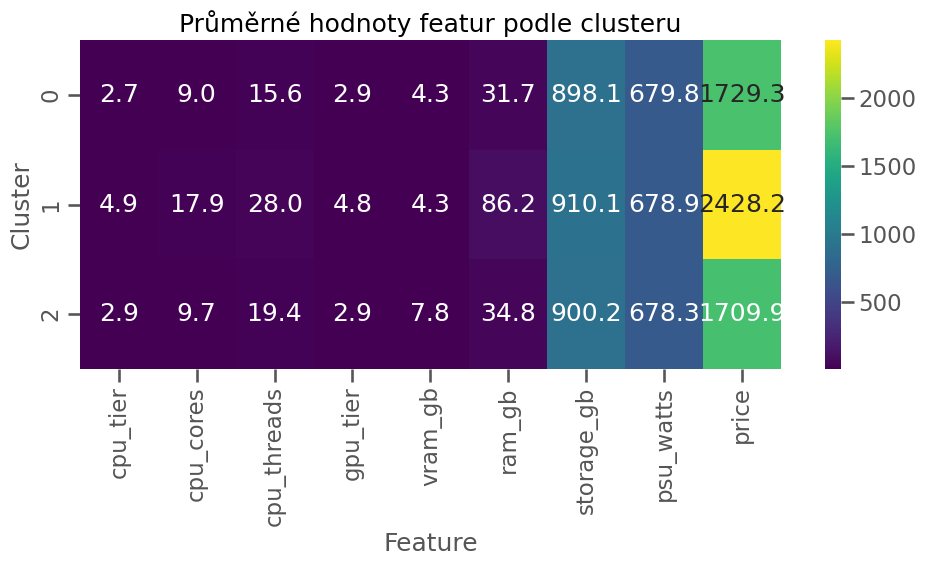

In [86]:
num_cols = [
    "cpu_tier", "cpu_cores", "cpu_threads",
    "gpu_tier", "vram_gb", "ram_gb",
    "storage_gb", "psu_watts", "price"
]

cluster_means = df_desktop_clusters.groupby("cluster")[num_cols].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(
    cluster_means,
    annot=True,
    fmt=".1f",
    cmap="viridis"
)
plt.title("Průměrné hodnoty featur podle clusteru")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()
